In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import itertools
from klassen import City, distanz, neighbour

In [2]:
df = pd.read_csv('msg_standorte_deutschland.csv')
#display (df)

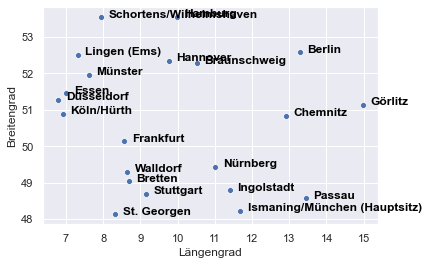

In [3]:
sns.set() 
ax = sns.scatterplot(y="Breitengrad", x="Längengrad", data=df)
for line in range(0,df.shape[0]):
     ax.text(df.Längengrad[line]+0.2, df.Breitengrad[line], df.msg_Standort[line], horizontalalignment='left', size='medium', color='black', weight='semibold')

Die Daten aus der Tabelle (Pandas Datenframe) werden genutzt um für jede Stadt eine Klasse City zu erzeugen, die die Kooridinaten und die Nummer der Stadt enthält.

In [4]:
cities = []

df2 = df.iloc[:4]

for row in df.itertuples():
    new = City(row.Längengrad, row.Breitengrad, row.Nummer, row.msg_Standort)
    cities.append(new)

# Nearest Neighbour Approach

Die Tour beginnt an der Start-Stadt, von da aus wird bezogen auf die Distanz der nächste Nachbar ausgewält und zur Tour hinzugefügt. Anschließend wird von da aus nach dem nächsten Nachbar gesucht usw. bis alle Städte besucht wurden. 

Dabei handelt es sich aber nur um eine Annäherung an die vermutlich beste Lösung. 

In [5]:
tour = [cities[0]]
unbesucht = cities[1:]
strecke = 0

while unbesucht:
    result = neighbour(tour[-1], unbesucht)
    tour.append(result[0])
    strecke += result[1]
    unbesucht.remove(result[0])

#die Reise zurück zum Start hinzufügen
strecke += distanz(tour[-1], cities[0])
tour.append(cities[0])



In [6]:
for c in tour:
    display (c.name)
display (strecke)

'Ismaning/München (Hauptsitz)'

'Ingolstadt'

'Nürnberg'

'Stuttgart'

'Bretten'

...

'Görlitz'

'Passau'

'St. Georgen'

'Ismaning/München (Hauptsitz)'

32.36643574103747

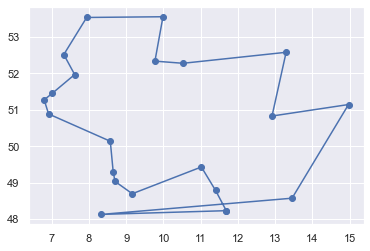

In [7]:
plt.plot([p.x for p in tour], [p.y for p in tour], "bo-")
plt.show()